# AISIT Database — Data Overview

**Pan-Arctic oxygen isotope ($\delta^{18}$O) and barium measurements**

*AISIT hackathon*

---

This notebook opens the AISIT database, has a look at what's inside,
filters it a few ways, and makes some simple plots.



## The science in one paragraph

Water containing the heavy oxygen isotope $^{18}$O evaporates less preferentiialy than its lighter isotopic counterpart $^{16}$O. Subsequent evaporation and precipitation of a water sample casues it to become isotopically *lighter*. The relative proportion of the two isotopes (combined with salinity), therefore acts as an efffective tracer of different water sources. We measure this as
$\delta^{18}$O, in parts per thousand (‰) against a standard:

- **Seawater** is near 0‰
- **Arctic rivers and precipitation** can be −20‰ or lower
- **Sea-ice meltwater** is only slightly light (about −2‰), because
  freezing removes the salt but barely touches the isotopes

## Database at a glance 

AISIT gathers 45,737 of these measurements from 99 source datasets,
everywhere north of 60°N, from December 1967 to August 2025.

## 1. Set up

We need three libraries: pandas for the table, numpy for maths,
matplotlib for plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Show plots in the notebook
%matplotlib inline

# Make the plots a bit bigger than the default
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Read the data

Keep the CSV in the same folder as this notebook and you can just name it.

The CSV file starts with 31 lines beginning with `#`.
Those are the metadata - title, citation, licence, processing notes - not
data. So we tell pandas to skip them (have a read of those lines at some point to understand the dataset's: schema, provenance and caveats).

In [2]:
df = pd.read_csv("AISIT_Database_1.0.0.csv",  low_memory=False ,skiprows=31)

df.head()

,Dataset,ISO8601_Datetime,Latitude_[degree_north],Longitude_[degree_east],Temperature_[Cel],CTD_Temperature_WOCE_Flag,CTD_Pressure_[dbar],Depth_From_Pressure_[meters_below_surface],Sample_Depth_[meters_below_surface],Combined_Depth_[meters_below_surface],...,Sample_ID,Cast_Number,Bottle_Number,Event,Rosette_Position,Platform,BIOPOLE,Freshwater,Freshwater_Source,Land_Based
0,ArcticNet,2016-06-09T17:25:00,68.4975,-56.7956,3.8784,NaN,362.852,358.896111,NaN,358.896111,...,NaN,3,1.0,NaN,NaN,NaN,False,False,NaN,False
1,ArcticNet,2016-06-09T17:33:00,68.4975,-56.7951,-0.9372,NaN,60.178,59.565520,NaN,59.565520,...,NaN,3,6.0,NaN,NaN,NaN,False,False,NaN,False
2,ArcticNet,2016-06-09T17:34:00,68.4975,-56.7948,-1.5417,NaN,50.106,49.597243,NaN,49.597243,...,NaN,3,7.0,NaN,NaN,NaN,False,False,NaN,False
3,ArcticNet,2016-06-09T17:38:00,68.4973,-56.7940,-0.9740,NaN,39.998,39.592847,NaN,39.592847,...,NaN,3,11.0,NaN,NaN,NaN,False,False,NaN,False
4,ArcticNet,2016-06-09T17:40:00,68.4973,-56.7936,0.5214,NaN,30.177,29.872039,NaN,29.872039,...,NaN,3,13.0,NaN,NaN,NaN,False,False,NaN,False


`skiprows=31` skips the metadata block. `low_memory=False` just stops
pandas printing a warning about mixed-up column types - you can ignore it.

## 2.5 Database Patch
After releasing the database, we unfortunately encountered an issue with the depth values of a specific dataset.

The corrections only apply to the *"healy_2016"* dataset and are as follows: 
- Both the "CTD_Pressure_[dbar]" and the "Depth_From_Pressure_[meters_below_surface]" must be replaced with **NaN** values.
- The "Sample_Depth_[meters_below_surface]" and "Combined_Depth_[meters_below_surface]" must be replaced with values of **8**. 

To correct these values please execte the following code:



In [3]:
mask = df["Dataset"] == "healy_2016"

df.loc[mask, "CTD_Pressure_[dbar]"] = np.nan
df.loc[mask, "Depth_From_Pressure_[meters_below_surface]"] = np.nan
df.loc[mask, "Sample_Depth_[meters_below_surface]"] = 8
df.loc[mask, "Combined_Depth_[meters_below_surface]"] = 8

## 3. Have a look around

Three aspects of the database worht knowing before investigating further: how much data is there, what are the
columns called, and how much data is missing?

In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 45737
Columns: 34


In [5]:
# The column names as written in the database
list(df.columns)

['Dataset',
 'ISO8601_Datetime',
 'Latitude_[degree_north]',
 'Longitude_[degree_east]',
 'Temperature_[Cel]',
 'CTD_Temperature_WOCE_Flag',
 'CTD_Pressure_[dbar]',
 'Depth_From_Pressure_[meters_below_surface]',
 'Sample_Depth_[meters_below_surface]',
 'Combined_Depth_[meters_below_surface]',
 'Delta_O18_[permillle]',
 'Delta_O18_WOCE_Flag_Translated',
 'Delta_O18_WOCE_Flag_Original',
 'O18_Standard',
 'Barium',
 'Barium_WOCE_Flag',
 'Barium_Units',
 'CTD_Salinity_[dimensionless]',
 'CTD_Salinity_WOCE_Flag',
 'Bottle_Salinity_[dimensionless]',
 'Bottle_Salinity_WOCE_Flag',
 'Cruise_ID',
 'Station_ID_Name',
 'Site_Number_Name',
 'Sample_ID',
 'Cast_Number',
 'Bottle_Number',
 'Event',
 'Rosette_Position',
 'Platform',
 'BIOPOLE',
 'Freshwater',
 'Freshwater_Source',
 'Land_Based']

## Flags
Note the flags that have been added in the database to ease filtering. These columns contain boolean values to aid analysis, for example "Freshwater" denotes whether a sample is freshwater or not, and "Land_Based" denotes whether the sampling was taken on land or at sea. Please see the schema within the metadata for further information on columns.  

In [6]:
# How many values does each column actually have?
df.count()

Dataset                                       45737
ISO8601_Datetime                              45737
Latitude_[degree_north]                       45737
Longitude_[degree_east]                       45737
Temperature_[Cel]                             36703
CTD_Temperature_WOCE_Flag                      3050
CTD_Pressure_[dbar]                           21636
Depth_From_Pressure_[meters_below_surface]    20204
Sample_Depth_[meters_below_surface]           27536
Combined_Depth_[meters_below_surface]         42552
Delta_O18_[permillle]                         45737
Delta_O18_WOCE_Flag_Translated                17814
Delta_O18_WOCE_Flag_Original                  17817
O18_Standard                                  45737
Barium                                         5531
Barium_WOCE_Flag                               2276
Barium_Units                                   5531
CTD_Salinity_[dimensionless]                  38422
CTD_Salinity_WOCE_Flag                        15886
Bottle_Salin

Some columns are full, others are mostly empty. That's to be expected (a water
bottle from 1975 didn't record what a modern CTD records). It does decide
what you can analyse:

- `Delta_O18` each of the 45,737 entries naturally has an O18 value.
- Salinity is there for most rows (not present for freshwater samples), split between a CTD and a bottle column.
  We'll merge those two shortly.
- `Barium` only has about 5,500 values, so barium work uses a much
  smaller slice. This refelcts its less abundant sampling in the field.
- `Combined_Depth`, is a merging of the two partial depth columns. See the schema in the CSV header for more details.

In [7]:
# value_counts() tallies up each unique string in the O18 standard column.
df["O18_Standard"].value_counts()

O18_Standard
VSMOW                18372
VSMOW (assumed)      10173
SMOW                  7938
VSMOW_SLAP scale      4635
VSMOW and GISP        3801
VSMOW2                 772
VSMOW2 and VSLAP2       46
Name: count, dtype: int64

In [8]:
df["Barium_Units"].value_counts()

Barium_Units
nmol/L     2481
nmol/kg    2194
ug/L        491
umol/kg     365
Name: count, dtype: int64

Worth noting from the ouput here:

**The isotope standard isn't the same everywhere.** Most rows use VSMOW,
but about 10,000 say `VSMOW (assumed)`. These are cases where ther original dataset didn't provide a standard and have been flagged as a possible cause, should the data not appear correct down the line.

**Barium comes in four different units.**  We'll convert to just one unit later.

In [9]:
# Quality flags. Blank means the source dataset didn't give one.
df["Delta_O18_WOCE_Flag_Translated"].value_counts(dropna=False)

Delta_O18_WOCE_Flag_Translated
NaN    27923
2.0    17402
3.0      154
1.0      125
6.0       70
4.0       63
Name: count, dtype: int64

The flags follow the WOCE convention:

| Flag | Meaning |
|:----:|:--------|
| 1 | Sample taken but not analysed |
| 2 | Good |
| 3 | Questionable |
| 4 | Bad |
| 6 | Average of repeat measurements |
| blank | No flag given |

**Blank means** ***unflagged***, **not** ***bad***. Dropping every blank would throw away
most of the database.

## 4. Shorter column names

For ease of use you may wish to rename the columns we're going to use to a shorthand.

In [10]:
df = df.rename(columns={
    "Dataset": "dataset",
    "Latitude_[degree_north]": "lat",
    "Longitude_[degree_east]": "lon",
    "Temperature_[Cel]": "temp",
    "Combined_Depth_[meters_below_surface]": "depth",
    #"Delta_O18_[permillle]": "d18O",
    "Delta_O18_[permillle]": "d18O",
    "Delta_O18_WOCE_Flag_Translated": "flag",
    "Barium": "barium",
    "Barium_Units": "barium_units",
    "CTD_Salinity_[dimensionless]": "salinity_ctd",
    "Bottle_Salinity_[dimensionless]": "salinity_bottle",
    "Station_ID_Name": "station",
    "Freshwater": "freshwater",
    "Freshwater_Source": "freshwater_source",
    "Land_Based": "land",
})

df.head()

,dataset,ISO8601_Datetime,lat,lon,temp,CTD_Temperature_WOCE_Flag,CTD_Pressure_[dbar],Depth_From_Pressure_[meters_below_surface],Sample_Depth_[meters_below_surface],depth,...,Sample_ID,Cast_Number,Bottle_Number,Event,Rosette_Position,Platform,BIOPOLE,freshwater,freshwater_source,land
0,ArcticNet,2016-06-09T17:25:00,68.4975,-56.7956,3.8784,NaN,362.852,358.896111,NaN,358.896111,...,NaN,3,1.0,NaN,NaN,NaN,False,False,NaN,False
1,ArcticNet,2016-06-09T17:33:00,68.4975,-56.7951,-0.9372,NaN,60.178,59.565520,NaN,59.565520,...,NaN,3,6.0,NaN,NaN,NaN,False,False,NaN,False
2,ArcticNet,2016-06-09T17:34:00,68.4975,-56.7948,-1.5417,NaN,50.106,49.597243,NaN,49.597243,...,NaN,3,7.0,NaN,NaN,NaN,False,False,NaN,False
3,ArcticNet,2016-06-09T17:38:00,68.4973,-56.7940,-0.9740,NaN,39.998,39.592847,NaN,39.592847,...,NaN,3,11.0,NaN,NaN,NaN,False,False,NaN,False
4,ArcticNet,2016-06-09T17:40:00,68.4973,-56.7936,0.5214,NaN,30.177,29.872039,NaN,29.872039,...,NaN,3,13.0,NaN,NaN,NaN,False,False,NaN,False


In [11]:
# Turn the date text into real dates, so we can pull the year out
df["date"] = pd.to_datetime(df["ISO8601_Datetime"])
df["year"] = df["date"].dt.year

# One salinity column: use the CTD value, or the bottle value if there isn't one
df["salinity"] = df["salinity_ctd"].fillna(df["salinity_bottle"])

df[["date", "year", "salinity", "d18O"]].head()

,date,year,salinity,d18O
0,2016-06-09 17:25:00,2016,34.6219,0.42
1,2016-06-09 17:33:00,2016,33.7826,-0.24
2,2016-06-09 17:34:00,2016,33.6925,-0.22
3,2016-06-09 17:38:00,2016,33.5913,-0.17
4,2016-06-09 17:40:00,2016,33.5408,-0.35


## 5. Filtering rows

This is the thing you'll do most. You write a condition, which gives True
or False for every row, then put it in square brackets to keep the True
ones:

```python
df["lat"] > 80        # True or False for each row
df[df["lat"] > 80]    # just the rows where it's True
```

Quick reminder: join conditions with `&` for "and" and `|` for "or", and put
brackets around each condition. Python's own `and` and `or` don't work
here.

In [12]:
# Seawater: not freshwater, and not on land. The ~ means "not".
seawater = df[(~df["freshwater"]) & (~df["land"])]

freshwater = df[df["freshwater"]]

print("All samples:", len(df))
print("Seawater:", len(seawater))
print("Freshwater:", len(freshwater))

All samples: 45737
Seawater: 38974
Freshwater: 6504


In [13]:
# Several conditions at once: shallow, far north, and salinity measured
surface = seawater[
    (seawater["depth"] < 10)
    & (seawater["lat"] > 70)
    & (seawater["salinity"].notna())
]

print("Near-surface samples north of 70N:", len(surface))
surface[["dataset", "year", "lat", "lon", "depth", "salinity", "d18O"]].head()

Near-surface samples north of 70N: 8603


,dataset,year,lat,lon,depth,salinity,d18O
280,ArcticNet,2016,71.2867,-70.5039,0.500000,24.4355,-5.37
295,ArcticNet,2016,73.8168,-80.4935,9.937031,31.2739,-2.31
296,ArcticNet,2016,73.8168,-80.4935,1.421161,29.6768,-3.13
312,ArcticNet,2016,74.1568,-80.4602,1.976328,31.8573,-2.10
328,ArcticNet,2016,74.4972,-80.5380,2.053486,31.3272,-2.35


### Picking out a region

A box of latitudes and longitudes is the quickest way to grab one sea.
Here's the Beaufort Gyre, north of Alaska, which holds a huge amount of
Arctic freshwater.

In [14]:
beaufort = seawater[
    (seawater["lat"] > 70)
    & (seawater["lat"] < 80)
    & (seawater["lon"] > -160)
    & (seawater["lon"] < -120)
]

print("Samples in the Beaufort box:", len(beaufort))

Samples in the Beaufort box: 9628


In [15]:
# Picking out one source dataset by name
jois = df[df["dataset"] == "JOIS_2016"]

print("JOIS 2016 samples:", len(jois))

# Which datasets contributed the most?
df["dataset"].value_counts().head(10)

JOIS 2016 samples: 542


dataset
GISS_O18_data_N_of_45N                9443
healy_2016                            6034
arct_carbn                            3991
Wateriso_Utah_Precip_data_N_of_60N    2364
LOCEAN_Wisotopes-V5                   2162
Wateriso_Utah_River_data_N_of_60N     1920
NABOS18                               1432
PACIFICA_32PZ20020819                  971
ARKXXII_2                              729
HLY_0301                               566
Name: count, dtype: int64

In [16]:
# Dropping the bad data: flags 3 (questionable) and 4 (bad)
good = df[(df["flag"] != 3) & (df["flag"] != 4)]

print("Dropped", len(df) - len(good), "rows")

Dropped 217 rows


## 6. Plots

Lets take a quick look at some aspects of the data. 

### 6.1 A histogram

A good way of checking the distribution of the data at a glance

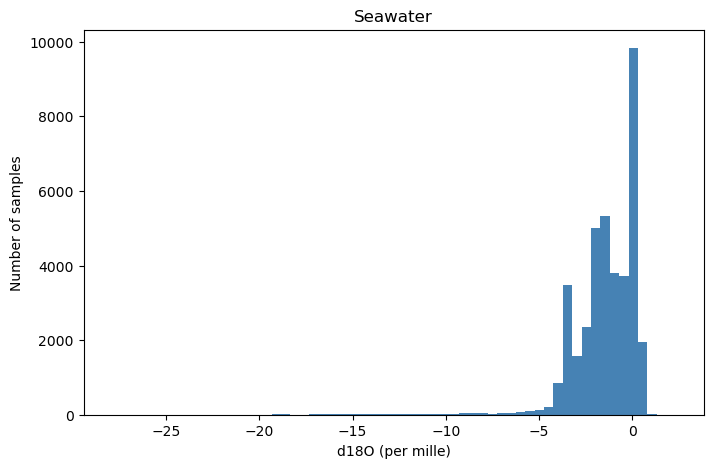

In [17]:
plt.hist(seawater["d18O"], bins=60, color="steelblue")
plt.xlabel("d18O (per mille)")
plt.ylabel("Number of samples")
plt.title("Seawater")
plt.show()

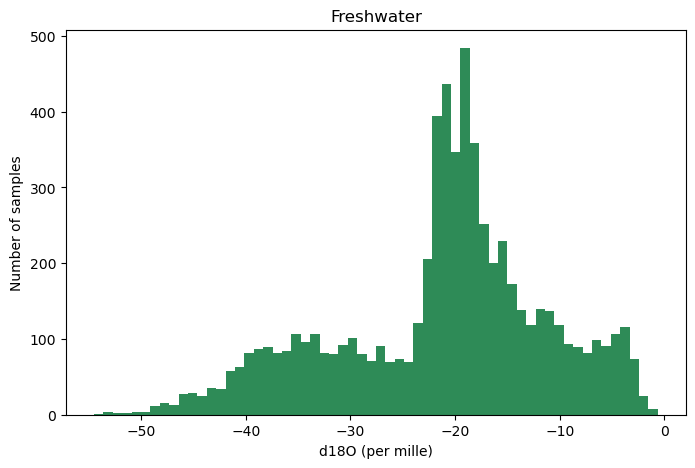

In [18]:
# Same plot for freshwater notice the difference in the x axis range.
plt.hist(freshwater["d18O"], bins=60, color="seagreen")
plt.xlabel("d18O (per mille)")
plt.ylabel("Number of samples")
plt.title("Freshwater")
plt.show()

### 6.2 x against y

 $\delta^{18}$O against salinity is a highly useful plot in this field.

Mixing two water masses gives a straight line on these axes. If Arctic
water were simply seawater diluted with river water, every point would
sit on one line from the river end (salinity 0, very light) up to Atlantic
water (salinity about 34.9, close to 0‰).

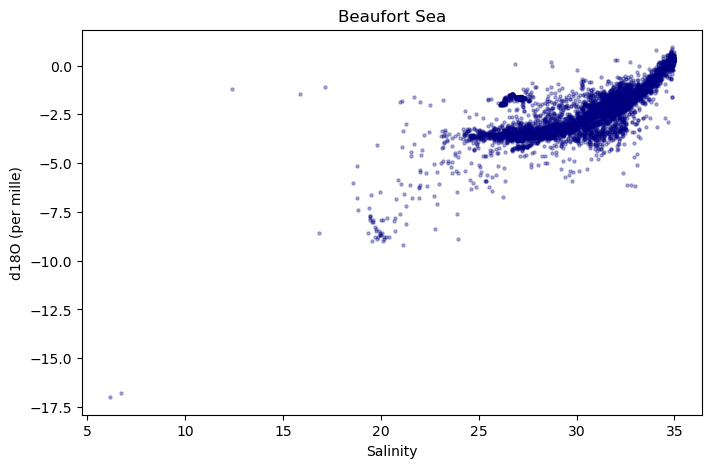

In [19]:
plt.scatter(beaufort["salinity"], beaufort["d18O"], s=5, alpha=0.3, color="navy")
plt.xlabel("Salinity")
plt.ylabel("d18O (per mille)")
plt.title("Beaufort Sea")
plt.show()

Now the same plot with colour showing a third variable. Adding `c=` and a
colour bar is a small change that tells you a lot more.

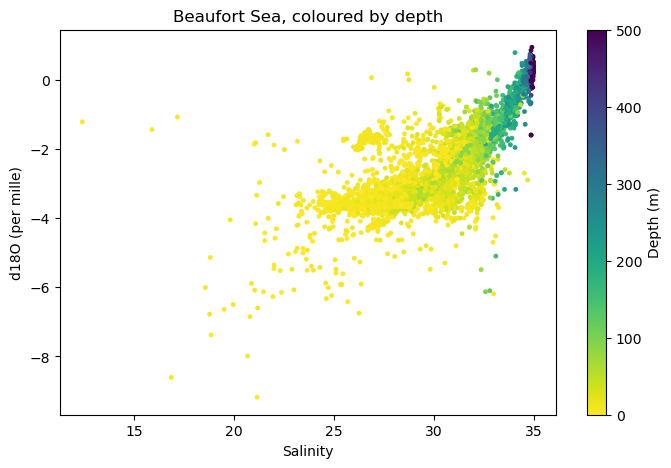

In [20]:
plt.scatter(beaufort["salinity"], beaufort["d18O"], c=beaufort["depth"],
            cmap="viridis_r", vmin=0, vmax=500, s=6)
plt.colorbar(label="Depth (m)")
plt.xlabel("Salinity")
plt.ylabel("d18O (per mille)")
plt.title("Beaufort Sea, coloured by depth")
plt.show()



### 7.3 A vertical profile



In [21]:
# One deep station from the 2016 Joint Ocean Ice Study in the Beaufort Gyre
station = df[(df["dataset"] == "JOIS_2016") & (df["station"] == "10")]
station = station.sort_values("depth")

print("Bottles:", len(station))
print("Deepest:", round(station["depth"].max()), "m")

Bottles: 24
Deepest: 3514 m


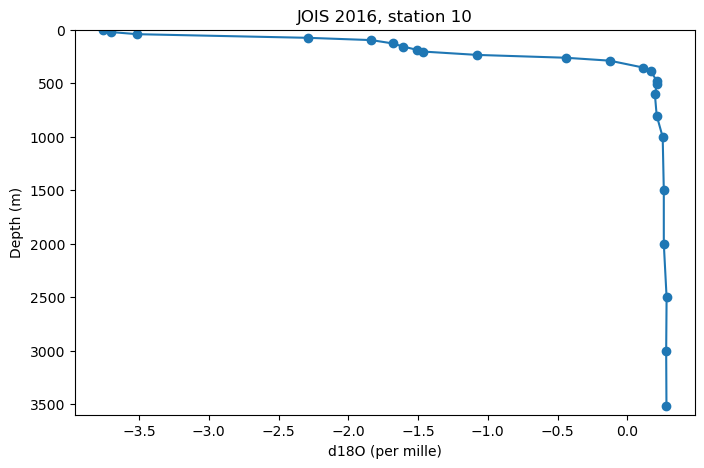

In [22]:
plt.plot(station["d18O"], station["depth"], marker="o")
plt.xlabel("d18O (per mille)")
plt.ylabel("Depth (m)")
plt.ylim(3600, 0)
plt.title("JOIS 2016, station 10")
plt.show()

Let's zoom in on the top 300m.

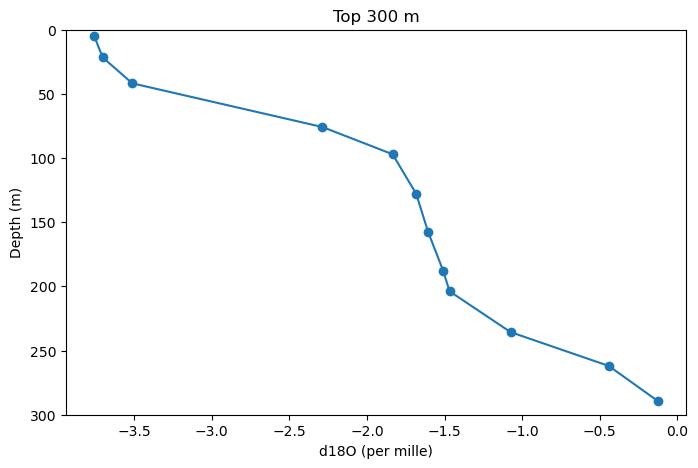

In [23]:
top = station[station["depth"] < 300]

plt.plot(top["d18O"], top["depth"], marker="o")
plt.xlabel("d18O (per mille)")
plt.ylabel("Depth (m)")
plt.ylim(300, 0)
plt.title("Top 300 m")
plt.show()

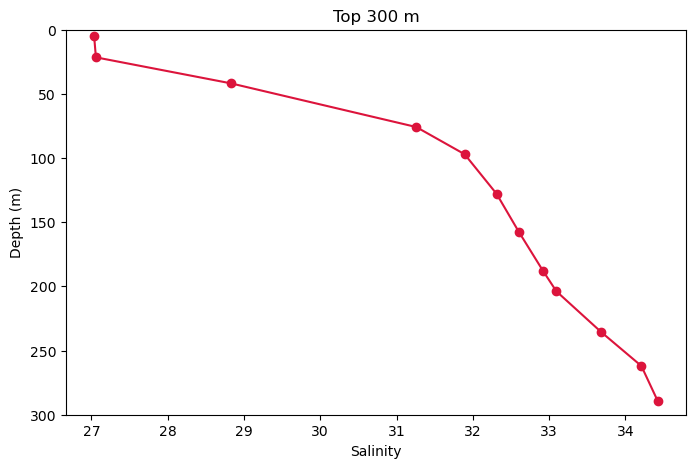

In [24]:
# Salinity at the same station, for comparison
plt.plot(top["salinity"], top["depth"], marker="o", color="crimson")
plt.xlabel("Salinity")
plt.ylabel("Depth (m)")
plt.ylim(300, 0)
plt.title("Top 300 m")
plt.show()

The two profiles are the same shape: fresh and light at the surface, salty
and heavy below.

### 7.4 A map

Proper map projections need the `cartopy` library, which is worth learning
later. For now, plotting longitude against latitude works fine.

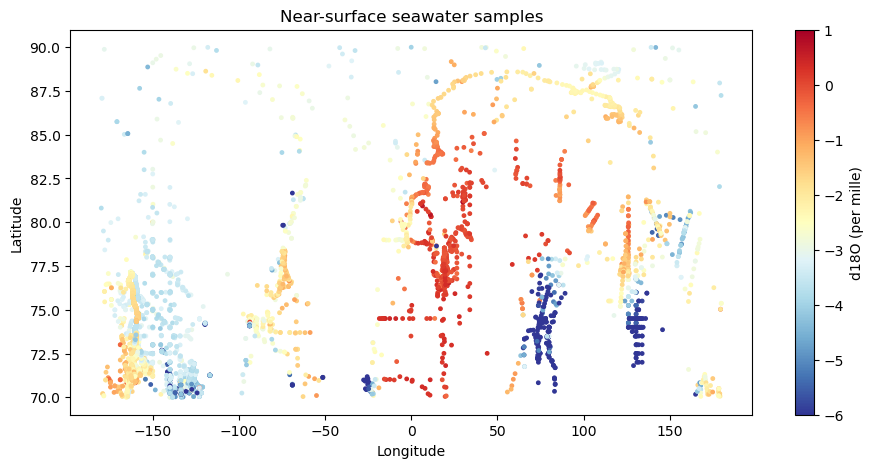

In [25]:
plt.figure(figsize=(11, 5))
plt.scatter(surface["lon"], surface["lat"], c=surface["d18O"],
            cmap="RdYlBu_r", vmin=-6, vmax=1, s=6)
plt.colorbar(label="d18O (per mille)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Near-surface seawater samples")
plt.show()

The light (blue) samples are where you'd expect: the Beaufort Gyre around
140°W, and the Siberian shelves, downstream of the big Arctic rivers. The
Atlantic side is much heavier.

Notice how patchy the coverage is. Worth remembering before you work out
any Arctic-wide average.


### Cartopy Map

A quick look at the map with land masses and from the polar perspective. This will require the cartopy package and a quick download of the land mass polygons. Don't worry if you can't get this to work immediately.

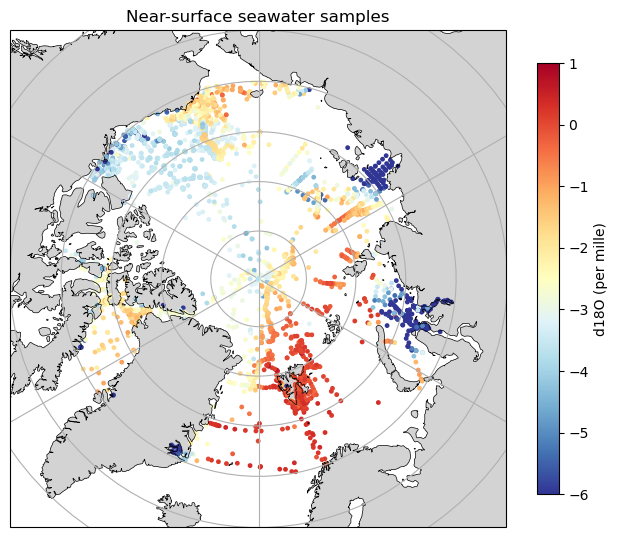

In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(8, 8))

# NorthPolarStereo looks down on the pole. This is the map's projection.
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Everything north of 65N. PlateCarree here means "these numbers are
# plain lon/lat degrees" — cartopy converts them for us.
ax.set_extent([-180, 180, 65, 90], crs=ccrs.PlateCarree())

# Land polygons and coastline, drawn before the data so points sit on top
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.coastlines(linewidth=0.5)
ax.gridlines()

# The same scatter as before, plus transform= to say the data is lon/lat
points = ax.scatter(surface["lon"], surface["lat"], c=surface["d18O"],
                    cmap="RdYlBu_r", vmin=-6, vmax=1, s=6,
                    transform=ccrs.PlateCarree())

plt.colorbar(points, label="d18O (per mille)", shrink=0.7)
plt.title("Near-surface seawater samples")
plt.show()


In [27]:

### 7.5 A bar chart

When was the Arctic sampled?

Object `sampled` not found.


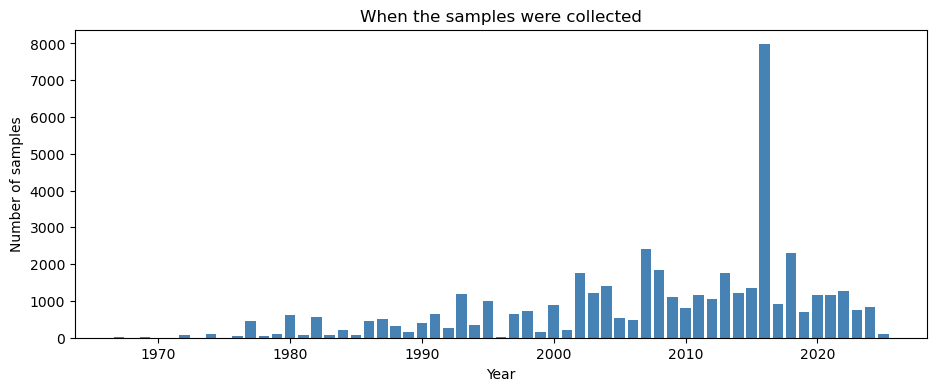

In [28]:
per_year = df["year"].value_counts().sort_index()

plt.figure(figsize=(11, 4))
plt.bar(per_year.index, per_year.values, color="steelblue")
plt.xlabel("Year")
plt.ylabel("Number of samples")
plt.title("When the samples were collected")
plt.show()

### And barium

Barium is the third tracer in the database, but has much sparser coverage. Arctic rivers carry much more of it than
seawater. But remember there were four different barium units in this
file, so pick one first. To do something meaningful with the barium one would have to first convert between the units

### Converting the barium units

The database reports barium four different ways. Before you plot or
average them together, put them all on one scale. We'll use **nmol/kg**.

Two conversions are needed:

**Mass to moles.** Barium's atomic weight is **137.327 g/mol**, so

    1 ug/L = 1 / 137.327 = 0.0072819 umol/L = 7.2819 nmol/L

**Per litre to per kilogram.** Divide by the density of the water in
kg/L. Seawater is denser than pure water, so a litre weighs more than a
kilogram and the number gets slightly smaller:

    nmol/kg = nmol/L / density

Use **1.025 kg/L** for Arctic seawater as a first pass, or **1.000 kg/L**
for river and lake samples. Surface Arctic densities really run from
about 1.020 to 1.028 kg/L, so a fixed value costs you well under 1% —
much less than the difference between the units themselves.

| From | To get nmol/kg | With density 1.025 |
|:---|:---|:---|
| `nmol/kg` | nothing to do | × 1 |
| `umol/kg` | × 1000 | × 1000 |
| `nmol/L` | ÷ density | × 0.9756 |
| `ug/L` | × 7.2819 ÷ density | × 7.1043 |

**If you want it properly:** density depends on salinity, temperature and
pressure, and you can calculate it for each sample with the `gsw` package
(TEOS-10), which needs `pip install gsw`:

```python
import gsw

SA = gsw.SA_from_SP(df["salinity"], df["pressure"], df["lon"], df["lat"])
CT = gsw.CT_from_t(SA, df["temp"], df["pressure"])
density = gsw.rho(SA, CT, df["pressure"]) / 1000   # kg/m3 -> kg/L
```

Worth doing if barium is central to your project. The fixed value is fine
for a first look.

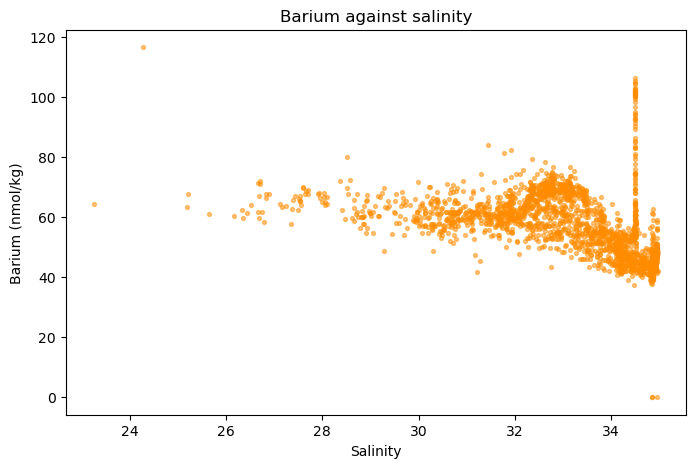

In [29]:
barium = df[df["barium_units"] == "nmol/kg"]

plt.scatter(barium["salinity"], barium["barium"], s=8, alpha=0.5, color="darkorange")
plt.xlabel("Salinity")
plt.ylabel("Barium (nmol/kg)")
plt.title("Barium against salinity")
plt.show()

## 8. Saving your work

Once you've filtered the data down, save it so your team can use the same
file.

In [30]:
shallow_beaufort = beaufort[beaufort["depth"] < 50]

shallow_beaufort.to_csv("beaufort_surface.csv", index=False)

print("Saved", len(shallow_beaufort), "rows")

Saved 3963 rows


## 9. Where to go next

### Final points to be aware of

- Read the metadata file - they list the dataset's own caveats and schema.
- Check the isotope standard; `VSMOW (assumed)` needs care
- Pick **one** barium unit before plotting or averaging
- A blank quality flag means *unflagged*, not *bad*
- Use `Combined_Depth`, not either of the partial depth columns
- Combine the CTD and bottle salinity columns
- Sampling is very patchy in space and time
- Cite the database (the citation is in the metadata at the top of the file)


### Links

- Database DOI: <https://doi.org/10.5285/0dfb14d6-73a9-4273-99ed-b231ca581b1d>
- AISIT project: <https://aisit.ac.uk/>
- pandas guide: <https://pandas.pydata.org/docs/user_guide/>
- matplotlib examples: <https://matplotlib.org/stable/gallery/>